# T1 - Tic Tac Toe

## 1. Importação das bibliotecas



In [4]:
import pandas as pd
import numpy as np

## 2. Carregamento do dataset original

In [7]:
columns = [
    'top_left',
    'top_middle',
    'top_right',
    'middle_left',
    'middle_middle',
    'middle_right',
    'bottom_left',
    'bottom_middle',
    'bottom_right',
    'class'
]

df = pd.read_csv(
    '/content/tic-tac-toe.data',
    names=columns
)

df.head()

,top_left,top_middle,top_right,middle_left,middle_middle,middle_right,bottom_left,bottom_middle,bottom_right,class
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


## 3. Análise do dataset

In [8]:
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

print('\nDistribuição da classe original:')
print(df['class'].value_counts())

print('\nValores ausentes:')
print(df.isnull().sum())

print('\nQuantidade de registros duplicados:')
print(df.duplicated().sum())

Quantidade de linhas: 958
Quantidade de colunas: 10

Distribuição da classe original:
class
positive    626
negative    332
Name: count, dtype: int64

Valores ausentes:
top_left         0
top_middle       0
top_right        0
middle_left      0
middle_middle    0
middle_right     0
bottom_left      0
bottom_middle    0
bottom_right     0
class            0
dtype: int64

Quantidade de registros duplicados:
0


In [9]:
for column in columns[:-1]:
    print(column, df[column].unique())

top_left ['x' 'o' 'b']
top_middle ['x' 'o' 'b']
top_right ['x' 'o' 'b']
middle_left ['x' 'o' 'b']
middle_middle ['o' 'b' 'x']
middle_right ['o' 'b' 'x']
bottom_left ['x' 'o' 'b']
bottom_middle ['o' 'x' 'b']
bottom_right ['o' 'x' 'b']


## 4. Ajeitar as classes

In [10]:
board_columns = [
    'top_left',
    'top_middle',
    'top_right',
    'middle_left',
    'middle_middle',
    'middle_right',
    'bottom_left',
    'bottom_middle',
    'bottom_right'
]

winning_lines = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
    [0, 3, 6],
    [1, 4, 7],
    [2, 5, 8],
    [0, 4, 8],
    [2, 4, 6]
]

In [11]:
def classify_board(row):
    board = row[board_columns].values

    for line in winning_lines:
        values = [board[i] for i in line]

        if all(value == 'x' for value in values):
            return 'X_VENCEU'

        if all(value == 'o' for value in values):
            return 'O_VENCEU'

    if 'b' not in board:
        return 'EMPATE'

    return 'TEM_JOGO'

In [12]:
df['game_state'] = df.apply(classify_board, axis=1)

df['game_state'].value_counts()

,count
game_state,
X_VENCEU,626
O_VENCEU,316
EMPATE,16


## 5. Validação dos estados do jogo

o dataset só tem estados finais entao a gente precisa representar a classe tem jogo. comecamos com o tabuleiro vazio, o X e o O sao os oponentes e assim que interrompe a partida temos vitória ou empate.

In [13]:
def generate_valid_states():
    valid_states = set()
    visited = set()

    def play(board, player):
        if board in visited:
            return

        visited.add(board)

        state = classify_board(
            pd.Series(dict(zip(board_columns, board)))
        )

        if board != ('b',) * 9:
            valid_states.add(board)

        if state != 'TEM_JOGO':
            return

        next_player = 'o' if player == 'x' else 'x'

        for position in range(9):
            if board[position] == 'b':
                new_board = list(board)
                new_board[position] = player

                play(tuple(new_board), next_player)

    play(('b',) * 9, 'x')

    return valid_states

In [14]:
valid_states = generate_valid_states()

df_valid = pd.DataFrame(
    list(valid_states),
    columns=board_columns
)

df_valid['game_state'] = df_valid.apply(
    classify_board,
    axis=1
)

print(f'Quantidade de estados válidos únicos: {len(df_valid)}')

print('\nDistribuição por classe:')
print(df_valid['game_state'].value_counts())

Quantidade de estados válidos únicos: 5477

Distribuição por classe:
game_state
TEM_JOGO    4519
X_VENCEU     626
O_VENCEU     316
EMPATE        16
Name: count, dtype: int64


In [15]:
#verificando se os 958 tabuleiros originais estão realmente contidos nos estados finais que geramos.

original_boards = set(
    map(tuple, df[board_columns].values)
)

generated_final_boards = set(
    map(
        tuple,
        df_valid[df_valid['game_state'] != 'TEM_JOGO'][board_columns].values
    )
)

print('Estados finais originais:', len(original_boards))
print('Estados finais gerados:', len(generated_final_boards))
print('Os conjuntos são iguais:', original_boards == generated_final_boards)

Estados finais originais: 958
Estados finais gerados: 958
Os conjuntos são iguais: True


**Resultado esperado:** os 958 estados finais do dataset original continuam representados, mas agora também temos estados intermediários válidos para a classe `TEM_JOGO`.

## 6. Balanceamento e seleção das amostras

In [16]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_valid,
    test_size=0.20,
    random_state=42,
    stratify=df_valid['game_state']
)

print('Treino:')
print(train_df['game_state'].value_counts())

print('\nTeste:')
print(test_df['game_state'].value_counts())

Treino:
game_state
TEM_JOGO    3614
X_VENCEU     501
O_VENCEU     253
EMPATE        13
Name: count, dtype: int64

Teste:
game_state
TEM_JOGO    905
X_VENCEU    125
O_VENCEU     63
EMPATE        3
Name: count, dtype: int64


In [17]:
train_sampled = pd.concat([
    train_df[train_df['game_state'] == 'TEM_JOGO'].sample(
        n=200,
        random_state=42
    ),
    train_df[train_df['game_state'] == 'X_VENCEU'].sample(
        n=200,
        random_state=42
    ),
    train_df[train_df['game_state'] == 'O_VENCEU'].sample(
        n=200,
        random_state=42
    )
])

In [18]:
empate_train = train_df[
    train_df['game_state'] == 'EMPATE'
]

empate_oversampled = empate_train.sample(
    n=200,
    replace=True,
    random_state=42
)

In [19]:
train_balanced = pd.concat([
    train_sampled,
    empate_oversampled
])

train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(train_balanced['game_state'].value_counts())

game_state
EMPATE      200
TEM_JOGO    200
O_VENCEU    200
X_VENCEU    200
Name: count, dtype: int64


## 7. Pré-processamento - Abordagem 1

In [20]:
board_mapping = {
    'x': 1,
    'o': -1,
    'b': 0
}

X_train_board = train_balanced[board_columns].replace(board_mapping)
X_test_board = test_df[board_columns].replace(board_mapping)

y_train = train_balanced['game_state']
y_test = test_df['game_state']

X_train_board.head()

/tmp/ipykernel_2400/1033364463.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_board = train_balanced[board_columns].replace(board_mapping)
/tmp/ipykernel_2400/1033364463.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_board = test_df[board_columns].replace(board_mapping)


,top_left,top_middle,top_right,middle_left,middle_middle,middle_right,bottom_left,bottom_middle,bottom_right
0,1,-1,1,1,-1,-1,-1,1,1
1,1,-1,1,1,-1,1,-1,1,-1
2,0,-1,0,0,0,1,-1,0,1
3,1,1,-1,1,-1,1,-1,0,-1
4,1,-1,1,0,-1,0,1,0,-1


In [21]:
print('Formato treino:', X_train_board.shape)
print('Formato teste:', X_test_board.shape)

print('\nExemplo:')
print(X_train_board.iloc[0])

Formato treino: (800, 9)
Formato teste: (1096, 9)

Exemplo:
top_left         1
top_middle      -1
top_right        1
middle_left      1
middle_middle   -1
middle_right    -1
bottom_left     -1
bottom_middle    1
bottom_right     1
Name: 0, dtype: int64


## 8. Pré-processamento - Abordagem 2

In [22]:
def extract_features(row):
    board = row[board_columns].values

    x_count = np.sum(board == 'x')
    o_count = np.sum(board == 'o')
    empty_count = np.sum(board == 'b')
    occupied = x_count + o_count

    lines_with_2_x = 0
    lines_with_2_o = 0

    for line in winning_lines:
        values = [board[i] for i in line]

        if values.count('x') == 2 and values.count('b') == 1:
            lines_with_2_x += 1

        if values.count('o') == 2 and values.count('b') == 1:
            lines_with_2_o += 1


    next_player = 0 if x_count == o_count else 1

    return pd.Series({
        'x_count': x_count,
        'o_count': o_count,
        'occupied': occupied,
        'lines_with_2_x': lines_with_2_x,
        'lines_with_2_o': lines_with_2_o,
        'empty_count': empty_count,
        'next_player': next_player
    })

In [23]:
X_train_features = train_balanced.apply(
    extract_features,
    axis=1
)

X_test_features = test_df.apply(
    extract_features,
    axis=1
)

X_train_features.head()

,x_count,o_count,occupied,lines_with_2_x,lines_with_2_o,empty_count,next_player
0,5,4,9,0,0,0,1
1,5,4,9,0,0,0,1
2,2,2,4,1,0,5,0
3,4,4,8,0,1,1,0
4,3,3,6,1,1,3,0


In [24]:
print('Formato treino:', X_train_features.shape)
print('Formato teste:', X_test_features.shape)

Formato treino: (800, 7)
Formato teste: (1096, 7)


In [25]:
display(X_train_board.head())
display(X_train_features.head())

,top_left,top_middle,top_right,middle_left,middle_middle,middle_right,bottom_left,bottom_middle,bottom_right
0,1,-1,1,1,-1,-1,-1,1,1
1,1,-1,1,1,-1,1,-1,1,-1
2,0,-1,0,0,0,1,-1,0,1
3,1,1,-1,1,-1,1,-1,0,-1
4,1,-1,1,0,-1,0,1,0,-1


,x_count,o_count,occupied,lines_with_2_x,lines_with_2_o,empty_count,next_player
0,5,4,9,0,0,0,1
1,5,4,9,0,0,0,1
2,2,2,4,1,0,5,0
3,4,4,8,0,1,1,0
4,3,3,6,1,1,3,0


## 9. k-NN


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

X_train_board_cv = train_df[board_columns].replace(board_mapping)
X_train_features_cv = train_df.apply(extract_features, axis=1)
y_train_cv = train_df['game_state']

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

/tmp/ipykernel_2400/4136196228.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_board_cv = train_df[board_columns].replace(board_mapping)


In [27]:
#abordagem 1
knn_board = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_knn_board = GridSearchCV(
    knn_board,
    knn_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_knn_board.fit(
    X_train_board_cv,
    y_train_cv
)

print('Melhores parâmetros:')
print(grid_knn_board.best_params_)

print('Melhor F1 na validação:')
print(grid_knn_board.best_score_)

best_knn_board = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=grid_knn_board.best_params_['knn__n_neighbors'],
        weights=grid_knn_board.best_params_['knn__weights']
    ))
])

best_knn_board.fit(
    X_train_board,
    y_train
)

pred_knn_board = best_knn_board.predict(X_test_board)

knn_board_accuracy = accuracy_score(y_test, pred_knn_board)
knn_board_precision = precision_score(
    y_test, pred_knn_board, average='macro', zero_division=0
)
knn_board_recall = recall_score(
    y_test, pred_knn_board, average='macro', zero_division=0
)
knn_board_f1 = f1_score(
    y_test, pred_knn_board, average='macro', zero_division=0
)

print('Accuracy:', knn_board_accuracy)
print('Precision:', knn_board_precision)
print('Recall:', knn_board_recall)
print('F1:', knn_board_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_knn_board, zero_division=0))

Melhores parâmetros:
{'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Melhor F1 na validação:
0.41636757158989557
Accuracy: 0.5
Precision: 0.37189079692523747
Recall: 0.5337002543190388
F1: 0.35219102770148664

Classification report:
              precision    recall  f1-score   support

      EMPATE       0.00      0.00      0.00         3
    O_VENCEU       0.22      0.98      0.36        63
    TEM_JOGO       0.94      0.44      0.60       905
    X_VENCEU       0.33      0.71      0.45       125

    accuracy                           0.50      1096
   macro avg       0.37      0.53      0.35      1096
weighted avg       0.82      0.50      0.57      1096



In [28]:
# abordagem 2
knn_features = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_knn_features = GridSearchCV(
    knn_features,
    knn_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_knn_features.fit(
    X_train_features_cv,
    y_train_cv
)

print('Melhores parâmetros:')
print(grid_knn_features.best_params_)

print('Melhor F1 na validação:')
print(grid_knn_features.best_score_)
best_knn_features = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=grid_knn_features.best_params_['knn__n_neighbors'],
        weights=grid_knn_features.best_params_['knn__weights']
    ))
])

best_knn_features.fit(
    X_train_features,
    y_train
)

pred_knn_features = best_knn_features.predict(X_test_features)

knn_features_accuracy = accuracy_score(y_test, pred_knn_features)
knn_features_precision = precision_score(
    y_test, pred_knn_features, average='macro', zero_division=0
)
knn_features_recall = recall_score(
    y_test, pred_knn_features, average='macro', zero_division=0
)
knn_features_f1 = f1_score(
    y_test, pred_knn_features, average='macro', zero_division=0
)

print('Accuracy:', knn_features_accuracy)
print('Precision:', knn_features_precision)
print('Recall:', knn_features_recall)
print('F1:', knn_features_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_knn_features, zero_division=0))

Melhores parâmetros:
{'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Melhor F1 na validação:
0.5271750894468952
Accuracy: 0.7901459854014599
Precision: 0.5088571100304995
Recall: 0.8933701657458564
F1: 0.5821810775429276

Classification report:
              precision    recall  f1-score   support

      EMPATE       0.18      1.00      0.30         3
    O_VENCEU       0.38      1.00      0.55        63
    TEM_JOGO       0.98      0.77      0.87       905
    X_VENCEU       0.49      0.80      0.61       125

    accuracy                           0.79      1096
   macro avg       0.51      0.89      0.58      1096
weighted avg       0.89      0.79      0.82      1096



In [29]:
# comparação entre as abordagens
knn_results = pd.DataFrame([
    {
        'Abordagem': 'Tabuleiro',
        'Accuracy': knn_board_accuracy,
        'Precision': knn_board_precision,
        'Recall': knn_board_recall,
        'F1': knn_board_f1
    },
    {
        'Abordagem': 'Features',
        'Accuracy': knn_features_accuracy,
        'Precision': knn_features_precision,
        'Recall': knn_features_recall,
        'F1': knn_features_f1
    }
])

knn_results

,Abordagem,Accuracy,Precision,Recall,F1
0,Tabuleiro,0.500000,0.371891,0.53370,0.352191
1,Features,0.790146,0.508857,0.89337,0.582181


## 10. MLP

In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=42
    ))
])

mlp_params = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (32, 16)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    mlp,
    mlp_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True
)

X_train_board_cv = X_train_board
y_train_cv = y_train

grid_mlp.fit(X_train_board_cv, y_train_cv)

print('Melhores parâmetros:')
print(grid_mlp.best_params_)
print('Melhor F1 na validação:')
print(grid_mlp.best_score_)


ValueError: 
All the 120 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


best_mlp = grid_mlp.best_estimator_
best_mlp.fit(X_train_board,a y_train)

pred_mlp = best_mlp.predict(X_test_board)

mlp_accuracy = accuracy_score(y_test, pred_mlp)
mlp_precision = precision_score(
    y_test, pred_mlp, average='macro', zero_division=0
)
mlp_recall = recall_score(
    y_test, pred_mlp, average='macro', zero_division=0
)
mlp_f1 = f1_score(
    y_test, pred_mlp, average='macro', zero_division=0
)

print('Accuracy:', mlp_accuracy)
print('Precision:', mlp_precision)
print('Recall:', mlp_recall)
print('F1:', mlp_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_mlp, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, pred_mlp)


In [ ]:
mlp_results = pd.DataFrame([{
    'Abordagem': 'MLP - Tabuleiro',
    'Accuracy': mlp_accuracy,
    'Precision': mlp_precision,
    'Recall': mlp_recall,
    'F1': mlp_f1
}])

mlp_results


## 11. Árvores de Decisão

In [35]:
import time
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold, validation_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

dt_X_board_cv = train_df[board_columns].replace(board_mapping)
dt_X_features_cv = train_df.apply(extract_features, axis=1)
dt_y_cv = train_df['game_state']

dt_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

/tmp/ipykernel_2400/4187931508.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt_X_board_cv = train_df[board_columns].replace(board_mapping)


In [36]:
def avaliar_arvore(nome, grid, X_tr, y_tr, X_te, y_te):
    """Treina a árvore final com os melhores parâmetros no treino balanceado
    e avalia no teste. Retorna o modelo, as predições e um dict de métricas."""
    modelo = DecisionTreeClassifier(**grid.best_params_, random_state=42)

    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    tempo_treino = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred = modelo.predict(X_te)
    tempo_pred = time.perf_counter() - t0

    resultado = {
        'Abordagem': nome,
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred, average='macro', zero_division=0),
        'Recall': recall_score(y_te, pred, average='macro', zero_division=0),
        'F1': f1_score(y_te, pred, average='macro', zero_division=0),
        'Acc. treino': accuracy_score(y_tr, modelo.predict(X_tr)),
        'F1 validação (CV)': grid.best_score_,
        'Tempo treino (s)': tempo_treino,
        'Tempo predição (s)': tempo_pred,
        'Profundidade': modelo.get_depth(),
        'Folhas': modelo.get_n_leaves()
    }
    return modelo, pred, resultado

In [37]:
# abordagem 1
dt_board = DecisionTreeClassifier(random_state=42)

grid_dt_board = GridSearchCV(
    dt_board,
    dt_params,
    scoring='f1_macro',
    cv=dt_cv,
    n_jobs=-1
)

grid_dt_board.fit(dt_X_board_cv, dt_y_cv)

print('Melhores parâmetros (tabuleiro):')
print(grid_dt_board.best_params_)
print('Melhor F1 na validação:', grid_dt_board.best_score_)

best_dt_board, pred_dt_board, res_dt_board = avaliar_arvore(
    'Tabuleiro', grid_dt_board,
    X_train_board, y_train, X_test_board, y_test
)

print('\nClassification report (tabuleiro):')
print(classification_report(y_test, pred_dt_board, zero_division=0))

Melhores parâmetros (tabuleiro):
{'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor F1 na validação: 0.6866409821603444

Classification report (tabuleiro):
              precision    recall  f1-score   support

      EMPATE       0.00      0.00      0.00         3
    O_VENCEU       0.26      0.84      0.40        63
    TEM_JOGO       0.96      0.60      0.74       905
    X_VENCEU       0.34      0.84      0.48       125

    accuracy                           0.64      1096
   macro avg       0.39      0.57      0.41      1096
weighted avg       0.85      0.64      0.69      1096



In [38]:
#abordagem 2
dt_features = DecisionTreeClassifier(random_state=42)

grid_dt_features = GridSearchCV(
    dt_features,
    dt_params,
    scoring='f1_macro',
    cv=dt_cv,
    n_jobs=-1
)

grid_dt_features.fit(dt_X_features_cv, dt_y_cv)

print('Melhores parâmetros (features):')
print(grid_dt_features.best_params_)
print('Melhor F1 na validação:', grid_dt_features.best_score_)

best_dt_features, pred_dt_features, res_dt_features = avaliar_arvore(
    'Features', grid_dt_features,
    X_train_features, y_train, X_test_features, y_test
)

print('\nClassification report (features):')
print(classification_report(y_test, pred_dt_features, zero_division=0))

Melhores parâmetros (features):
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor F1 na validação: 0.45419258926863126

Classification report (features):
              precision    recall  f1-score   support

      EMPATE       0.18      1.00      0.30         3
    O_VENCEU       0.24      1.00      0.39        63
    TEM_JOGO       1.00      0.61      0.76       905
    X_VENCEU       0.41      0.89      0.56       125

    accuracy                           0.66      1096
   macro avg       0.46      0.87      0.50      1096
weighted avg       0.89      0.66      0.71      1096



In [39]:
#comparacao
dt_results = pd.DataFrame([res_dt_board, res_dt_features])

dt_results

,Abordagem,Accuracy,Precision,Recall,F1,Acc. treino,F1 validação (CV),Tempo treino (s),Tempo predição (s),Profundidade,Folhas
0,Tabuleiro,0.643248,0.389843,0.571422,0.405064,1.0000,0.686641,0.005943,0.001883,11,199
1,Features,0.663321,0.457706,0.873934,0.502336,0.8825,0.454193,0.011204,0.007246,5,11


In [40]:
t0 = time.perf_counter()
_ = test_df[board_columns].replace(board_mapping)
dt_tempo_prep_board = time.perf_counter() - t0

t0 = time.perf_counter()
_ = test_df.apply(extract_features, axis=1)
dt_tempo_prep_features = time.perf_counter() - t0

dt_custo_preprocessamento = pd.DataFrame([
    {'Abordagem': 'Tabuleiro', 'Tempo de pré-processamento do teste (s)': dt_tempo_prep_board},
    {'Abordagem': 'Features', 'Tempo de pré-processamento do teste (s)': dt_tempo_prep_features}
])

dt_custo_preprocessamento

/tmp/ipykernel_2400/273060804.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _ = test_df[board_columns].replace(board_mapping)


,Abordagem,Tempo de pré-processamento do teste (s)
0,Tabuleiro,0.024452
1,Features,1.715452


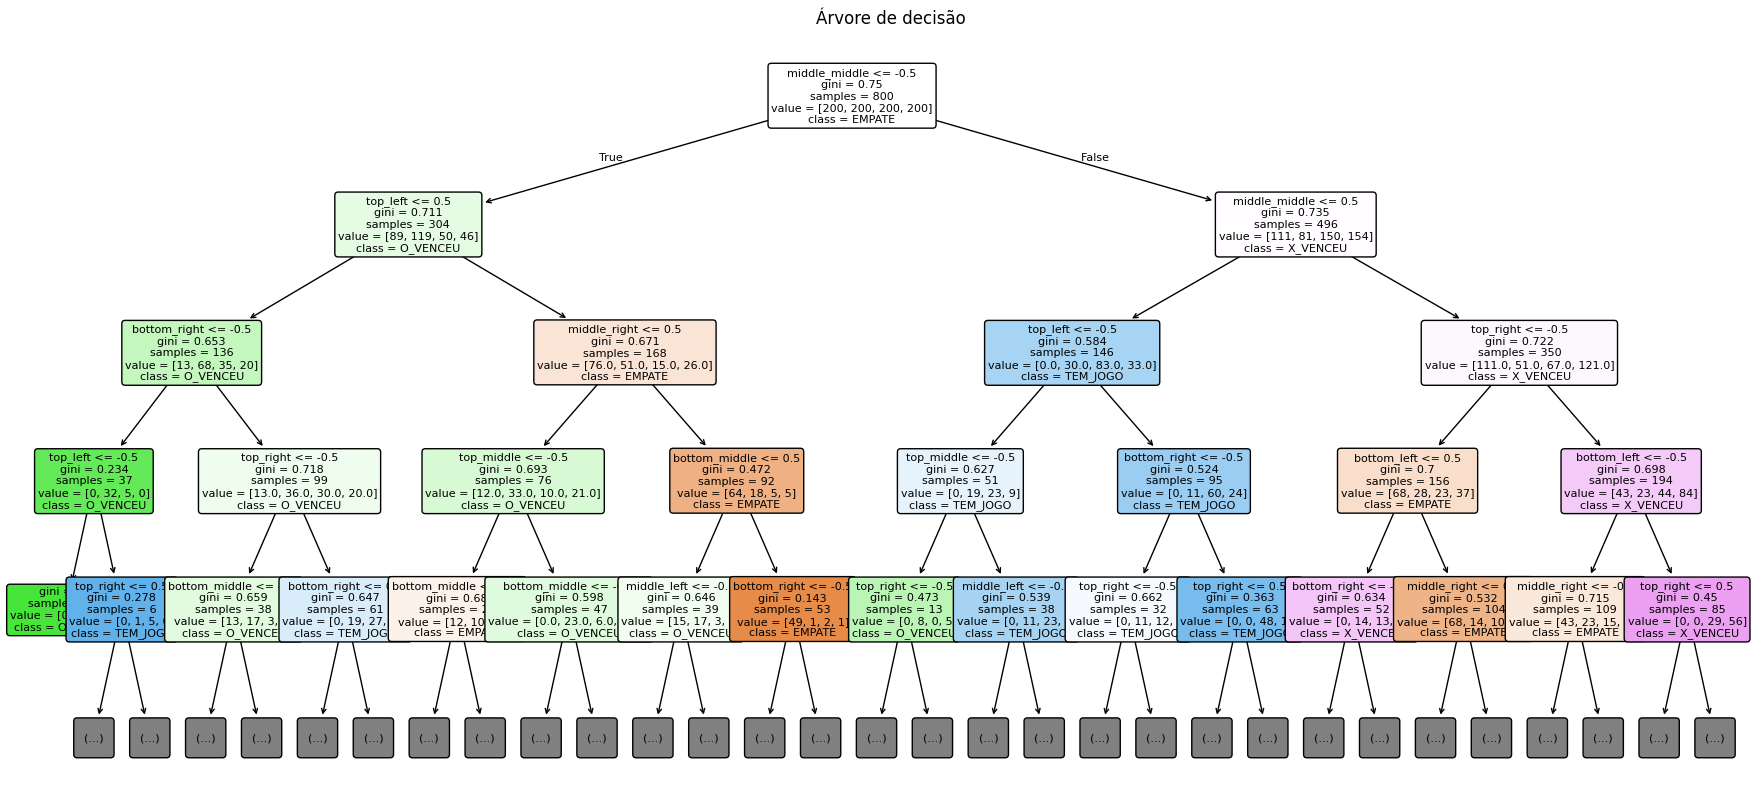

In [44]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt_board,
    feature_names=list(X_train_board.columns),
    class_names=list(best_dt_board.classes_),
    filled=True, rounded=True, max_depth=4, fontsize=8
)
plt.title('Árvore de decisão')
plt.show()

## 12. SVM

In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

svm_params = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    svm,
    svm_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_svm.fit(X_train_board_cv, y_train_cv)

print('Melhores parâmetros:')
print(grid_svm.best_params_)
print('Melhor F1 na validação:')
print(grid_svm.best_score_)


In [ ]:
best_svm = grid_svm.best_estimator_
best_svm.fit(X_train_board, y_train)

pred_svm = best_svm.predict(X_test_board)

svm_accuracy = accuracy_score(y_test, pred_svm)
svm_precision = precision_score(
    y_test, pred_svm, average='macro', zero_division=0
)
svm_recall = recall_score(
    y_test, pred_svm, average='macro', zero_division=0
)
svm_f1 = f1_score(
    y_test, pred_svm, average='macro', zero_division=0
)

print('Accuracy:', svm_accuracy)
print('Precision:', svm_precision)
print('Recall:', svm_recall)
print('F1:', svm_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_svm, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, pred_svm)


In [ ]:
svm_results = pd.DataFrame([{
    'Abordagem': 'SVM - Tabuleiro',
    'Accuracy': svm_accuracy,
    'Precision': svm_precision,
    'Recall': svm_recall,
    'F1': svm_f1
}])

svm_results


## 13. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}


In [ ]:
rf_board = RandomForestClassifier(
    random_state=42
)

grid_rf_board = GridSearchCV(
    rf_board,
    rf_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_rf_board.fit(
    X_train_board_cv,
    y_train_cv
)

print('Melhores parâmetros:')
print(grid_rf_board.best_params_)

print('Melhor F1 na validação:')
print(grid_rf_board.best_score_)


Melhores parâmetros:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Melhor F1 na validação:
0.6139192822087833


In [ ]:
best_rf_board = RandomForestClassifier(
    **grid_rf_board.best_params_,
    random_state=42
)

best_rf_board.fit(
    X_train_board,
    y_train
)

pred_rf_board = best_rf_board.predict(X_test_board)

rf_board_accuracy = accuracy_score(y_test, pred_rf_board)
rf_board_precision = precision_score(
    y_test, pred_rf_board, average='macro', zero_division=0
)
rf_board_recall = recall_score(
    y_test, pred_rf_board, average='macro', zero_division=0
)
rf_board_f1 = f1_score(
    y_test, pred_rf_board, average='macro', zero_division=0
)

print('Accuracy:', rf_board_accuracy)
print('Precision:', rf_board_precision)
print('Recall:', rf_board_recall)
print('F1:', rf_board_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_rf_board, zero_division=0))


Accuracy: 0.7299270072992701
Precision: 0.44241205918837495
Recall: 0.6530579672016136
F1: 0.47572605675412316

Classification report:
              precision    recall  f1-score   support

      EMPATE       0.00      0.00      0.00         3
    O_VENCEU       0.28      0.97      0.44        63
    TEM_JOGO       0.99      0.68      0.81       905
    X_VENCEU       0.50      0.96      0.66       125

    accuracy                           0.73      1096
   macro avg       0.44      0.65      0.48      1096
weighted avg       0.89      0.73      0.77      1096



In [ ]:
rf_features = RandomForestClassifier(
    random_state=42
)

grid_rf_features = GridSearchCV(
    rf_features,
    rf_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_rf_features.fit(
    X_train_features_cv,
    y_train_cv
)

print('Melhores parâmetros:')
print(grid_rf_features.best_params_)

print('Melhor F1 na validação:')
print(grid_rf_features.best_score_)


Melhores parâmetros:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Melhor F1 na validação:
0.4101474018418494


In [ ]:
best_rf_features = RandomForestClassifier(
    **grid_rf_features.best_params_,
    random_state=42
)

best_rf_features.fit(
    X_train_features,
    y_train
)

pred_rf_features = best_rf_features.predict(X_test_features)

rf_features_accuracy = accuracy_score(y_test, pred_rf_features)
rf_features_precision = precision_score(
    y_test, pred_rf_features, average='macro', zero_division=0
)
rf_features_recall = recall_score(
    y_test, pred_rf_features, average='macro', zero_division=0
)
rf_features_f1 = f1_score(
    y_test, pred_rf_features, average='macro', zero_division=0
)

print('Accuracy:', rf_features_accuracy)
print('Precision:', rf_features_precision)
print('Recall:', rf_features_recall)
print('F1:', rf_features_f1)

print('\nClassification report:')
print(classification_report(y_test, pred_rf_features, zero_division=0))


Accuracy: 0.7846715328467153
Precision: 0.5239576765447667
Recall: 0.9175690607734807
F1: 0.6051629717275566

Classification report:
              precision    recall  f1-score   support

      EMPATE       0.23      1.00      0.38         3
    O_VENCEU       0.39      1.00      0.57        63
    TEM_JOGO       1.00      0.75      0.86       905
    X_VENCEU       0.47      0.92      0.62       125

    accuracy                           0.78      1096
   macro avg       0.52      0.92      0.61      1096
weighted avg       0.90      0.78      0.81      1096



In [ ]:
rf_results = pd.DataFrame([
    {
        'Abordagem': 'Tabuleiro',
        'Accuracy': rf_board_accuracy,
        'Precision': rf_board_precision,
        'Recall': rf_board_recall,
        'F1': rf_board_f1
    },
    {
        'Abordagem': 'Features',
        'Accuracy': rf_features_accuracy,
        'Precision': rf_features_precision,
        'Recall': rf_features_recall,
        'F1': rf_features_f1
    }
])

rf_results


,Abordagem,Accuracy,Precision,Recall,F1
0,Tabuleiro,0.729927,0.442412,0.653058,0.475726
1,Features,0.784672,0.523958,0.917569,0.605163


In [ ]:
rf_weighted_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

rf_weighted = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

grid_rf_weighted = GridSearchCV(
    rf_weighted,
    rf_weighted_params,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid_rf_weighted.fit(
    X_train_features_cv,
    y_train_cv
)

print('Melhores parâmetros:')
print(grid_rf_weighted.best_params_)
print('Melhor F1 na validação:')
print(grid_rf_weighted.best_score_)


Melhores parâmetros:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor F1 na validação:
0.6045964065052328


In [ ]:
best_rf_weighted = grid_rf_weighted.best_estimator_

pred_rf_weighted = best_rf_weighted.predict(X_test_features)

rf_weighted_accuracy = accuracy_score(y_test, pred_rf_weighted)
rf_weighted_precision = precision_score(
    y_test, pred_rf_weighted, average='macro', zero_division=0
)
rf_weighted_recall = recall_score(
    y_test, pred_rf_weighted, average='macro', zero_division=0
)
rf_weighted_f1 = f1_score(
    y_test, pred_rf_weighted, average='macro', zero_division=0
)

print('Accuracy:', rf_weighted_accuracy)
print('Precision:', rf_weighted_precision)
print('Recall:', rf_weighted_recall)
print('F1:', rf_weighted_f1)
print('\nClassification report:')
print(classification_report(y_test, pred_rf_weighted, zero_division=0))


Accuracy: 0.7974452554744526
Precision: 0.5322898304831858
Recall: 0.9214364640883977
F1: 0.6157468365766852

Classification report:
              precision    recall  f1-score   support

      EMPATE       0.23      1.00      0.38         3
    O_VENCEU       0.42      1.00      0.59        63
    TEM_JOGO       1.00      0.77      0.87       905
    X_VENCEU       0.48      0.92      0.63       125

    accuracy                           0.80      1096
   macro avg       0.53      0.92      0.62      1096
weighted avg       0.91      0.80      0.82      1096



In [ ]:
rf_final_results = pd.DataFrame([
    {
        'Modelo': 'Random Forest balanceado por amostragem',
        'Accuracy': rf_features_accuracy,
        'Precision': rf_features_precision,
        'Recall': rf_features_recall,
        'F1': rf_features_f1
    },
    {
        'Modelo': 'Random Forest class_weight',
        'Accuracy': rf_weighted_accuracy,
        'Precision': rf_weighted_precision,
        'Recall': rf_weighted_recall,
        'F1': rf_weighted_f1
    }
])

rf_final_results


,Modelo,Accuracy,Precision,Recall,F1
0,Random Forest balanceado por amostragem,0.784672,0.523958,0.917569,0.605163
1,Random Forest class_weight,0.797445,0.532290,0.921436,0.615747


## 14. Comparação dos resultados

## 15. Exportação dos resultados

In [ ]:
import joblib
from pathlib import Path

pasta_modelos = Path('/workspaces/T1-IA/modelos')
pasta_modelos.mkdir(parents=True, exist_ok=True)

modelos = {
    'knn': 'best_knn_board',
    'random_forest': 'best_rf_board',
    'svm': 'best_svm_board',
    'mlp': 'best_mlp_board',
    'arvore_decisao': 'best_dt_board'
}

for nome, variavel in modelos.items():
    if variavel in globals():
        caminho = pasta_modelos / f'{nome}.pkl'

        if caminho.exists():
            caminho.unlink()

        joblib.dump(globals()[variavel], caminho)

        print(f'✅ {nome} exportado: {caminho}')
    else:
        print(f'⏭ {nome} ainda não disponível')

✅ knn exportado: /workspaces/T1-IA/modelos/knn.pkl
✅ random_forest exportado: /workspaces/T1-IA/modelos/random_forest.pkl
⏭ svm ainda não disponível
⏭ mlp ainda não disponível
⏭ arvore_decisao ainda não disponível
